In [1]:
import pandas as pd
import numpy as np
import random
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.decomposition import PCA
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.optimizers import Adam
import tensorflow as tf
import seaborn as sns
from sklearn.ensemble import IsolationForest
import joblib
os.chdir('Resources/')

In [2]:
df = pd.read_csv('5_Preprocessed_Data.csv')

X = df.drop(['HeartDisease'], axis='columns')
Y = df[['HeartDisease']]

AUC for train size 0.1: 0.7234676164982032
AUC for train size 0.2: 0.7861473146233496
AUC for train size 0.3: 0.8065011413457011
AUC for train size 0.4: 0.8303185518109882
AUC for train size 0.5: 0.8652646695749254
AUC for train size 0.6: 0.8833742266251434
AUC for train size 0.7: 0.8951335812863584
AUC for train size 0.8: 0.9268801972183385
AUC for train size 0.9: 0.9689153439153441


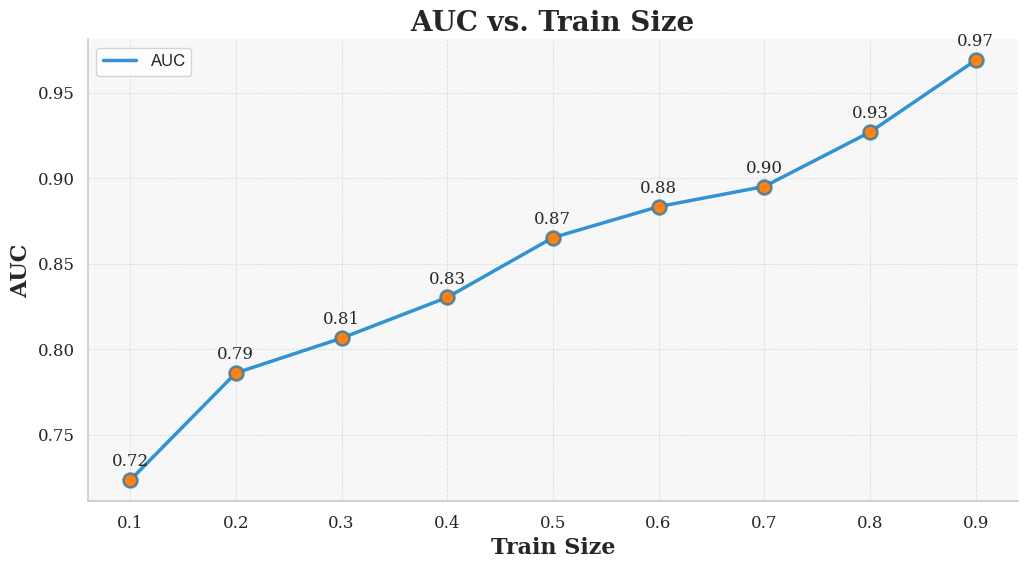

In [3]:
train_sizes = np.linspace(0.1, 0.9, 9)
AUCs_dtc = []
model_dtc = None

for train_size in train_sizes:
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=train_size, random_state=4686)
    
    dtc = DecisionTreeClassifier(random_state=4686)
    model_dtc = dtc.fit(X_train, Y_train.values.ravel()) 
    
    pred = model_dtc.predict(X_test)
    auc_dtc = roc_auc_score(Y_test, pred)
    
    AUCs_dtc.append(auc_dtc)
    print(f"AUC for train size {train_size:.1f}: {auc_dtc}")

np.savetxt('7_dtc.txt', AUCs_dtc)

sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
plt.plot(train_sizes, AUCs_dtc, linestyle='-', linewidth=2.5, markersize=10, color='#007acc', markerfacecolor='#ff7f0e', markeredgewidth=2, markeredgecolor='#007acc', alpha=0.8)

plt.xlabel('Train Size', fontsize=16, fontweight='bold', family='serif')
plt.ylabel('AUC', fontsize=16, fontweight='bold', family='serif')
plt.title('AUC vs. Train Size', fontsize=20, fontweight='bold', family='serif')

plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
plt.gca().set_facecolor('#f7f7f7')

for i, txt in enumerate(AUCs_dtc):
    plt.annotate(f"{txt:.2f}", (train_sizes[i], AUCs_dtc[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=12, family='serif')

plt.xticks(fontsize=12, family='serif')
plt.yticks(fontsize=12, family='serif')

plt.legend(['AUC'], fontsize=12)

sns.despine()

for i, txt in enumerate(AUCs_dtc):
    plt.plot(train_sizes[i], AUCs_dtc[i], marker='o', markersize=10, color='#ff7f0e', alpha=0.9)
    plt.plot(train_sizes[i], AUCs_dtc[i], marker='o', markersize=10, color='#007acc', markerfacecolor='#ff7f0e', markeredgewidth=2, markeredgecolor='#007acc', alpha=0.6)

plt.show()

AUC for train size 0.1: 0.6553357984769516
AUC for train size 0.2: 0.7115654322894542
AUC for train size 0.3: 0.7429136629971143
AUC for train size 0.4: 0.783568060945021
AUC for train size 0.5: 0.8080991337444822
AUC for train size 0.6: 0.845324661707928
AUC for train size 0.7: 0.8523660163749373
AUC for train size 0.8: 0.855244608231104
AUC for train size 0.9: 0.9144444444444445


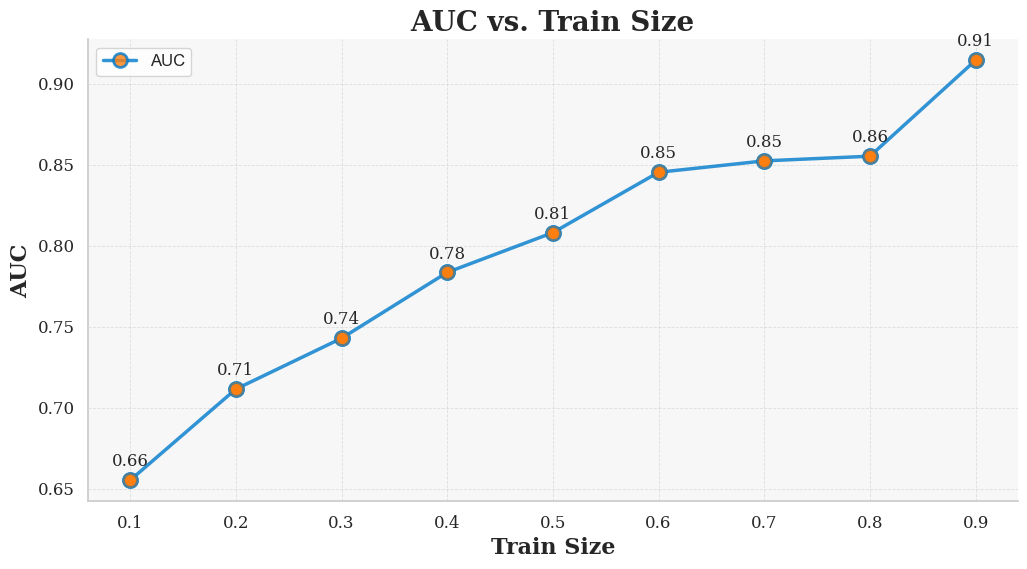

In [4]:
train_sizes = np.linspace(0.1, 0.9, 9)
AUCs_pca = []

for i, train_size in enumerate(train_sizes):
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=train_size, random_state=1347)
    
    pca = PCA(n_components=9)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    dtc_pca = DecisionTreeClassifier(random_state=1347)
    dtc_pca.fit(X_train_pca, Y_train.values.ravel())
    
    pred_pca = dtc_pca.predict(X_test_pca)
    auc_pca = roc_auc_score(Y_test, pred_pca)

    AUCs_pca.append(auc_pca)
    print(f"AUC for train size {train_size:.1f}: {auc_pca}")

np.savetxt('7_dtc_pca.txt', AUCs_pca)

sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
plt.plot(train_sizes, AUCs_pca, marker='o', linestyle='-', linewidth=2.5, markersize=10, color='#007acc', markerfacecolor='#ff7f0e', markeredgewidth=2, markeredgecolor='#007acc', alpha=0.8)

plt.xlabel('Train Size', fontsize=16, fontweight='bold', family='serif')
plt.ylabel('AUC', fontsize=16, fontweight='bold', family='serif')
plt.title('AUC vs. Train Size', fontsize=20, fontweight='bold', family='serif')

plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
plt.gca().set_facecolor('#f7f7f7')

for i, txt in enumerate(AUCs_pca):
    plt.annotate(f"{txt:.2f}", (train_sizes[i], AUCs_pca[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=12, family='serif')

plt.xticks(fontsize=12, family='serif')
plt.yticks(fontsize=12, family='serif')

plt.legend(['AUC'], fontsize=12)

sns.despine()

for i, txt in enumerate(AUCs_pca):
    plt.plot(train_sizes[i], AUCs_pca[i], marker='o', markersize=10, color='#ff7f0e', alpha=0.9)
    plt.plot(train_sizes[i], AUCs_pca[i], marker='o', markersize=10, color='#007acc', markerfacecolor='#ff7f0e', markeredgewidth=2, markeredgecolor='#007acc', alpha=0.6)

plt.show()

AUC for train size 0.1: 0.7176828570774897
AUC for train size 0.2: 0.7287765919803795
AUC for train size 0.3: 0.773486885752341
AUC for train size 0.4: 0.8099828129870918
AUC for train size 0.5: 0.8526180146473492
AUC for train size 0.6: 0.8734331397834416
AUC for train size 0.7: 0.8885131383132316
AUC for train size 0.8: 0.9170985424193346
AUC for train size 0.9: 0.9719657650464117


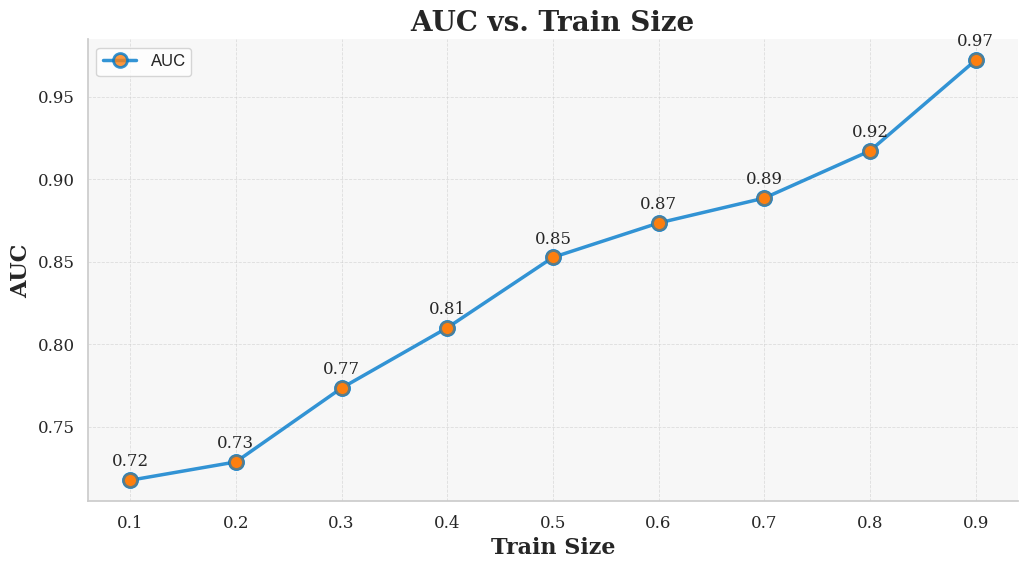

In [5]:
train_sizes = np.linspace(0.1, 0.9, 9)
AUCs_isolation = []

for i, train_size in enumerate(train_sizes):
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=train_size, random_state=1120)

    clf = IsolationForest(n_estimators=173, contamination=0.08, random_state=1120, max_samples=204)
    outliers = clf.fit_predict(X_train)
    X_train = X_train[outliers == 1]
    Y_train = Y_train[outliers == 1]

    corr_matrix = X_train.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
    X_train_selected = X_train.drop(to_drop, axis=1)
    X_test_selected = X_test.drop(to_drop, axis=1)

    dtc_isolation = DecisionTreeClassifier(random_state=1120, criterion='gini')
    dtc_isolation.fit(X_train_selected, Y_train.values.ravel())

    Y_pred = dtc_isolation.predict(X_test_selected)
    auc_isolation = roc_auc_score(Y_test, Y_pred)

    AUCs_isolation.append(auc_isolation)
    print(f"AUC for train size {train_size:.1f}: {auc_isolation}")

np.savetxt('7_dtc_isolation.txt', AUCs_isolation)

sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
plt.plot(train_sizes, AUCs_isolation, marker='o', linestyle='-', linewidth=2.5, markersize=10, color='#007acc', markerfacecolor='#ff7f0e', markeredgewidth=2, markeredgecolor='#007acc', alpha=0.8)

plt.xlabel('Train Size', fontsize=16, fontweight='bold', family='serif')
plt.ylabel('AUC', fontsize=16, fontweight='bold', family='serif')
plt.title('AUC vs. Train Size', fontsize=20, fontweight='bold', family='serif')

plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
plt.gca().set_facecolor('#f7f7f7')

for i, txt in enumerate(AUCs_isolation):
    plt.annotate(f"{txt:.2f}", (train_sizes[i], AUCs_isolation[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=12, family='serif')

plt.xticks(fontsize=12, family='serif')
plt.yticks(fontsize=12, family='serif')

plt.legend(['AUC'], fontsize=12)

sns.despine()

for i, txt in enumerate(AUCs_isolation):
    plt.plot(train_sizes[i], AUCs_isolation[i], marker='o', markersize=10, color='#ff7f0e', alpha=0.9)
    plt.plot(train_sizes[i], AUCs_isolation[i], marker='o', markersize=10, color='#007acc', markerfacecolor='#ff7f0e', markeredgewidth=2, markeredgecolor='#007acc', alpha=0.6)

plt.show()

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
AUC for train size 0.1: 0.7047866369949587


c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
AUC for train size 0.2: 0.7480881204844316


c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
AUC for train size 0.7: 0.8641853059956508


c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
AUC for train size 0.8: 0.891692231631256


c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
AUC for train size 0.9: 0.9364420186679323


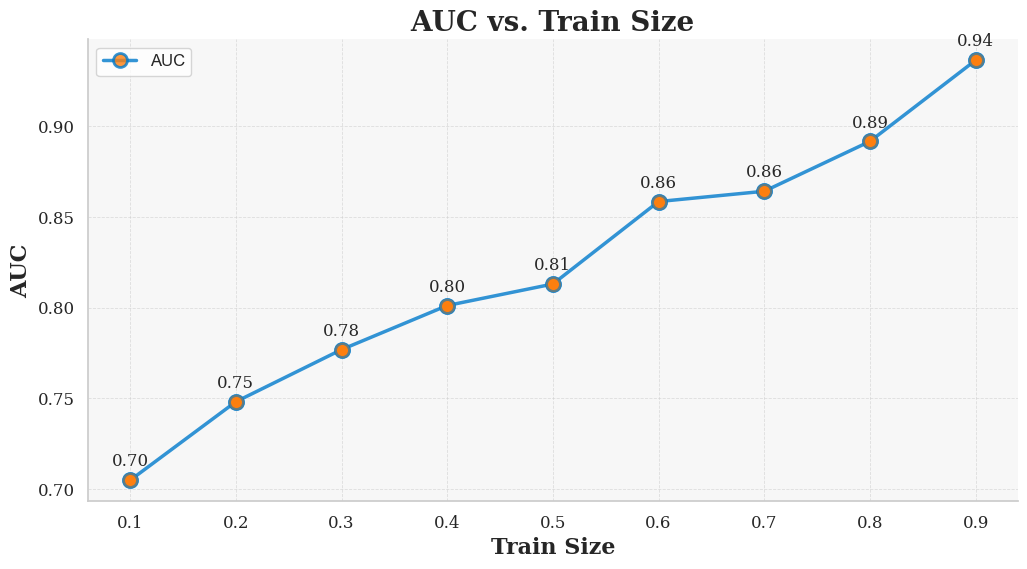

In [6]:
AUCs_lstm = []
seed = 637

for i in range(1, 10):
    np.random.seed(seed)
    tf.random.set_seed(104)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=i * 0.1, random_state=seed)

    X_train_reshaped = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
    X_test_reshaped = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

    model = Sequential()
    model.add(LSTM(11, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))
    model.add(Dropout(0.01 * 4))
    model.add(Dense(1, activation='sigmoid'))

    optimizer = Adam(learning_rate=1/13)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['auc'])

    model.fit(X_train_reshaped, Y_train, epochs=229, batch_size=10000, verbose=0)

    X_train_features = model.predict(X_train_reshaped)
    X_test_features = model.predict(X_test_reshaped)

    dtc_lstm = DecisionTreeClassifier(random_state=seed)
    dtc_lstm.fit(X_train_features, Y_train.values.ravel())

    Y_pred = dtc_lstm.predict(X_test_features)
    auc_lstm = roc_auc_score(Y_test, Y_pred)

    AUCs_lstm.append(auc_lstm)
    print(f"AUC for train size {0.1 * i:.1f}: {auc_lstm}")

np.savetxt('7_dtc_lstm.txt', AUCs_lstm)

sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
plt.plot(train_sizes, AUCs_lstm, marker='o', linestyle='-', linewidth=2.5, markersize=10, color='#007acc', markerfacecolor='#ff7f0e', markeredgewidth=2, markeredgecolor='#007acc', alpha=0.8)

plt.xlabel('Train Size', fontsize=16, fontweight='bold', family='serif')
plt.ylabel('AUC', fontsize=16, fontweight='bold', family='serif')
plt.title('AUC vs. Train Size', fontsize=20, fontweight='bold', family='serif')

plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
plt.gca().set_facecolor('#f7f7f7')

for i, txt in enumerate(AUCs_lstm):
    plt.annotate(f"{txt:.2f}", (train_sizes[i], AUCs_lstm[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=12, family='serif')

plt.xticks(fontsize=12, family='serif')
plt.yticks(fontsize=12, family='serif')

plt.legend(['AUC'], fontsize=12)

sns.despine()

for i, txt in enumerate(AUCs_lstm):
    plt.plot(train_sizes[i], AUCs_lstm[i], marker='o', markersize=10, color='#ff7f0e', alpha=0.9)
    plt.plot(train_sizes[i], AUCs_lstm[i], marker='o', markersize=10, color='#007acc', markerfacecolor='#ff7f0e', markeredgewidth=2, markeredgecolor='#007acc', alpha=0.6)

plt.show()

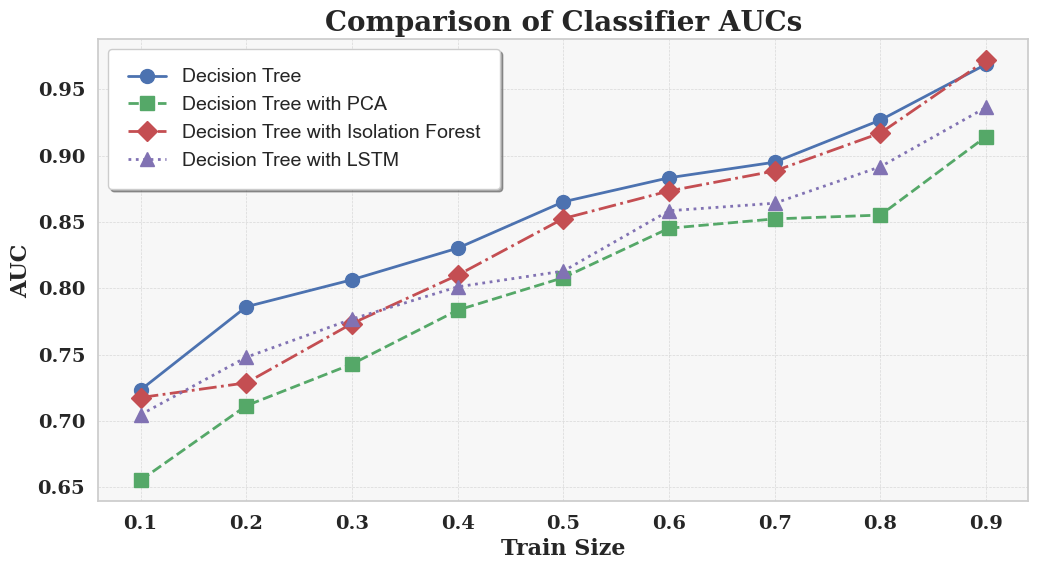

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

plt.plot(train_sizes, AUCs_dtc, marker='o', label='Decision Tree', linestyle='-', color='b', markersize=10, linewidth=2)
plt.plot(train_sizes, AUCs_pca, marker='s', label='Decision Tree with PCA', linestyle='--', color='g', markersize=10, linewidth=2)
plt.plot(train_sizes, AUCs_isolation, marker='D', label='Decision Tree with Isolation Forest', linestyle='-.', color='r', markersize=10, linewidth=2)
plt.plot(train_sizes, AUCs_lstm, marker='^', label='Decision Tree with LSTM', linestyle=':', color='m', markersize=10, linewidth=2)

plt.title('Comparison of Classifier AUCs', size=20, fontweight='bold', family='serif')
plt.xlabel('Train Size', fontsize=16, fontweight='bold', family='serif')
plt.ylabel('AUC', fontsize=16, fontweight='bold', family='serif')
plt.xticks(fontsize=14, fontweight='bold', family='serif')
plt.yticks(fontsize=14, fontweight='bold', family='serif')
plt.legend(loc='best', fontsize=14, frameon=True, fancybox=True, shadow=True, borderpad=1)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.gca().set_facecolor('#f7f7f7')

plt.savefig('Images/7_Comparison_of_DT_classifier_AUCs.png')

plt.show()

In [8]:
joblib.dump(model_dtc, '7_DT_Model.joblib')
joblib.dump(dtc_pca, '7_DT_PCA_Model.joblib')
joblib.dump(dtc_isolation, '7_DT_Isolation_Model.joblib')
joblib.dump(dtc_lstm, '7_DT_LSTM_Model.joblib')

['7_DT_LSTM_Model.joblib']